In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split



In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


In [4]:
dataset = datasets.ImageFolder(
    "../data/raw/plantvillage dataset/color",
    transform=transform
)

In [5]:
## Train-validation spilt
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])


In [6]:
## create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [7]:
## Define MLP model
class MLP(nn.Module):
    def __init__(self, num_classes):
        super(MLP, self).__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 224 * 224, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [8]:
## Initialize model
model = MLP(num_classes=len(dataset.classes))
model = model.to(device)

In [9]:
## Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [10]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

epochs = 5

for epoch in range(epochs):

    # ----- TRAINING -----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ----- VALIDATION -----
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% "
          f"|| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("MLP Training Completed ✅")

Epoch [1/5] Train Loss: 3.6796 | Train Acc: 11.40% || Val Loss: 3.1470 | Val Acc: 13.78%
Epoch [2/5] Train Loss: 3.1062 | Train Acc: 16.06% || Val Loss: 2.9956 | Val Acc: 20.53%
Epoch [3/5] Train Loss: 2.7780 | Train Acc: 25.63% || Val Loss: 2.6162 | Val Acc: 29.99%
Epoch [4/5] Train Loss: 2.2951 | Train Acc: 35.16% || Val Loss: 2.1356 | Val Acc: 39.57%
Epoch [5/5] Train Loss: 1.9529 | Train Acc: 43.16% || Val Loss: 1.8429 | Val Acc: 45.15%
MLP Training Completed ✅


In [ ]:
torch.save(model.state_dict(), "mlp_model.pth")


In [ ]:
checkpoint = {
    "epoch": epochs,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses,
    "train_accuracies": train_accuracies,
    "val_accuracies": val_accuracies
}

torch.save(checkpoint, "mlp_checkpoint.pth")

print("Model and history saved successfully ✅")


Model and history saved successfully ✅


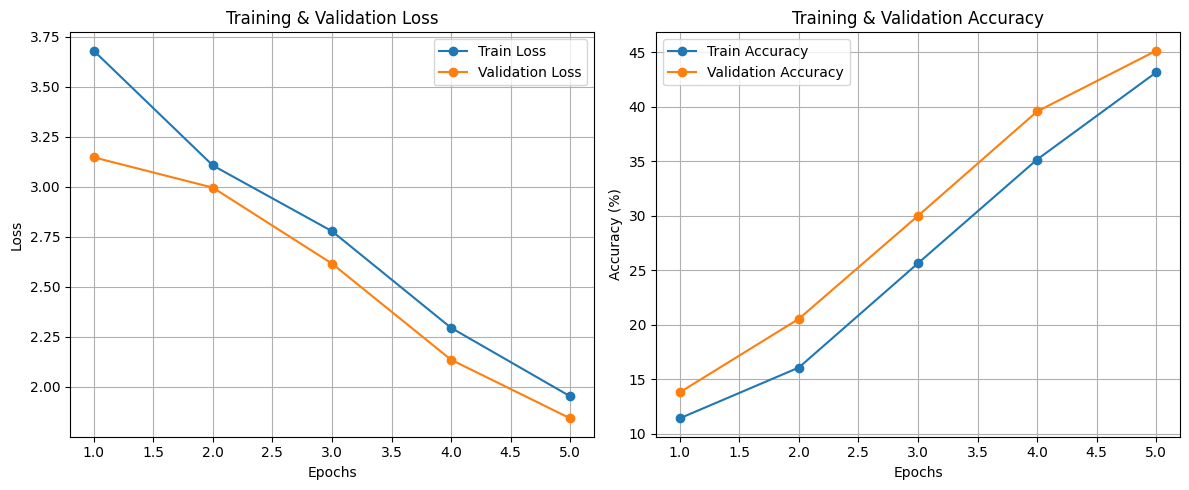

In [13]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# -------- LOSS PLOT --------
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, marker='o', label="Train Loss")
plt.plot(epochs_range, val_losses, marker='o', label="Validation Loss")
plt.title("Training & Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# -------- ACCURACY PLOT --------
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, marker='o', label="Train Accuracy")
plt.plot(epochs_range, val_accuracies, marker='o', label="Validation Accuracy")
plt.title("Training & Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#cnn model define
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    

In [ ]:
#initialize cnn model
cnn_model = SimpleCNN(num_classes=len(dataset.classes)).to(device)

In [16]:
#loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

In [18]:
cnn_model = SimpleCNN(num_classes=len(dataset.classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

cnn_train_losses = []
cnn_val_losses = []
cnn_train_accuracies = []
cnn_val_accuracies = []

best_val_acc = 0.0
epochs = 20

for epoch in range(epochs):

    # -------- TRAINING --------
    cnn_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    cnn_train_losses.append(train_loss)
    cnn_train_accuracies.append(train_acc)

    # -------- VALIDATION --------
    cnn_model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = cnn_model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100 * correct / total

    cnn_val_losses.append(val_loss)
    cnn_val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% "
          f"|| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # -------- SAVE BEST MODEL --------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(cnn_model.state_dict(), "cnn_best_model.pth")
        print("Best model saved!")

# -------- SAVE FINAL MODEL --------
torch.save(cnn_model.state_dict(), "cnn_final_model.pth")

print("✅ Training completed.")
print("✅ Best model saved as cnn_best_model.pth")
print("✅ Final model saved as cnn_final_model.pth")

Epoch [1/20] Train Loss: 0.9192 | Train Acc: 72.80% || Val Loss: 0.4372 | Val Acc: 86.21%
Best model saved!
Epoch [2/20] Train Loss: 0.3267 | Train Acc: 89.49% || Val Loss: 0.3130 | Val Acc: 89.91%
Best model saved!
Epoch [3/20] Train Loss: 0.1880 | Train Acc: 93.88% || Val Loss: 0.3004 | Val Acc: 91.02%
Best model saved!
Epoch [4/20] Train Loss: 0.1232 | Train Acc: 96.02% || Val Loss: 0.3553 | Val Acc: 90.07%
Epoch [5/20] Train Loss: 0.0898 | Train Acc: 97.02% || Val Loss: 0.3933 | Val Acc: 90.24%
Epoch [6/20] Train Loss: 0.0711 | Train Acc: 97.67% || Val Loss: 0.3658 | Val Acc: 90.74%
Epoch [7/20] Train Loss: 0.0595 | Train Acc: 98.05% || Val Loss: 0.3486 | Val Acc: 92.16%
Best model saved!
Epoch [8/20] Train Loss: 0.0556 | Train Acc: 98.20% || Val Loss: 0.3644 | Val Acc: 91.73%
Epoch [9/20] Train Loss: 0.0482 | Train Acc: 98.52% || Val Loss: 0.3984 | Val Acc: 91.01%
Epoch [10/20] Train Loss: 0.0374 | Train Acc: 98.90% || Val Loss: 0.3363 | Val Acc: 93.08%
Best model saved!
Epoch [11

In [20]:
import os
import shutil

# Create main models folder if not exists
os.makedirs("../models", exist_ok=True)

# Move files from notebooks/models to main models
shutil.move("models/cnn_best_model.pth", "../models/cnn_best_model.pth")
shutil.move("models/cnn_final_model.pth", "../models/cnn_final_model.pth")

print("✅ Files moved successfully!")

✅ Files moved successfully!


In [22]:
import torch
import os

# Ensure main models folder exists
os.makedirs("../models", exist_ok=True)

# Save training history in MAIN models folder
history = {
    "train_losses": cnn_train_losses,
    "val_losses": cnn_val_losses,
    "train_accuracies": cnn_train_accuracies,
    "val_accuracies": cnn_val_accuracies
}

torch.save(history, "../models/cnn_training_history.pth")

print("✅ History saved inside main models folder!")

✅ History saved inside main models folder!


In [24]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------- EXACT SAME ARCHITECTURE --------
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=38):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# -------- LOAD MODEL --------
cnn_model = SimpleCNN(num_classes=38).to(device)

cnn_model.load_state_dict(
    torch.load("../models/cnn_best_model.pth", map_location=device)
)

cnn_model.eval()

print("✅ CNN model reloaded successfully!")


# -------- LOAD HISTORY --------
history = torch.load("../models/cnn_training_history.pth")

cnn_train_losses = history["train_losses"]
cnn_val_losses = history["val_losses"]
cnn_train_accuracies = history["train_accuracies"]
cnn_val_accuracies = history["val_accuracies"]

print("✅ Training history reloaded successfully!")

✅ CNN model reloaded successfully!
✅ Training history reloaded successfully!


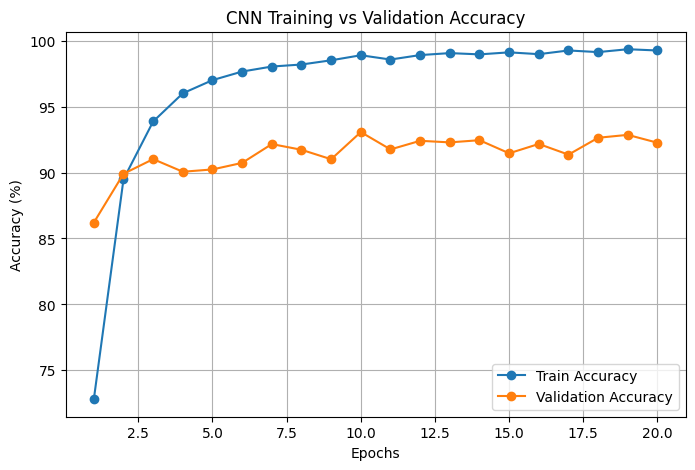

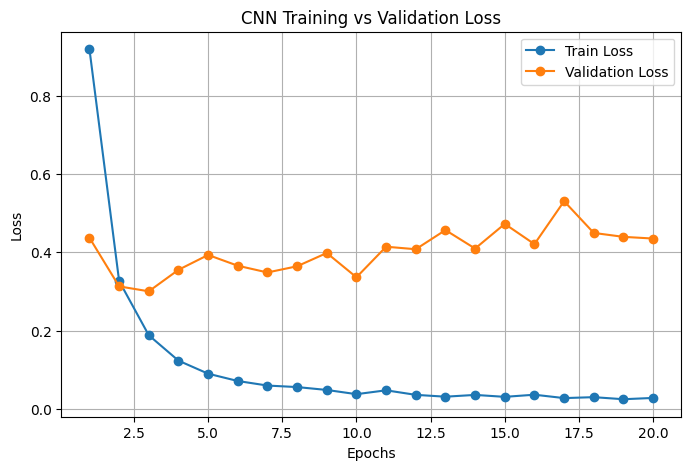

In [25]:
import matplotlib.pyplot as plt

# Number of epochs
epochs = range(1, len(cnn_train_losses) + 1)

# -------- Accuracy Plot --------
plt.figure(figsize=(8,5))
plt.plot(epochs, cnn_train_accuracies, marker='o')
plt.plot(epochs, cnn_val_accuracies, marker='o')
plt.title("CNN Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.grid(True)
plt.show()


# -------- Loss Plot --------
plt.figure(figsize=(8,5))
plt.plot(epochs, cnn_train_losses, marker='o')
plt.plot(epochs, cnn_val_losses, marker='o')
plt.title("CNN Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train Loss", "Validation Loss"])
plt.grid(True)
plt.show()

✅ Confusion matrix created successfully!


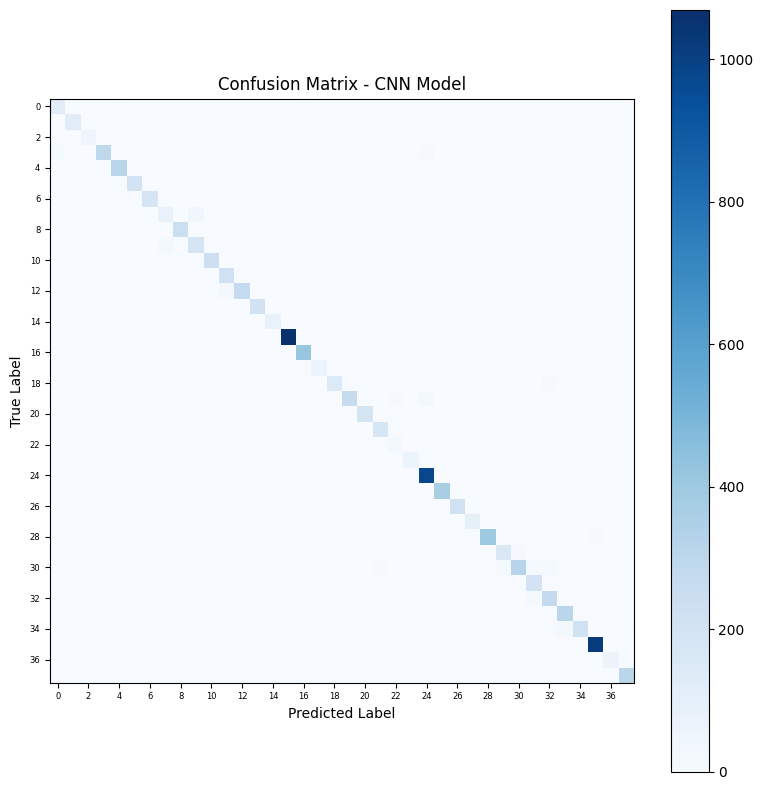

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# -------------------------------
# Collect predictions from model
# -------------------------------

cnn_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = cnn_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# -------------------------------
# Create Confusion Matrix (NumPy)
# -------------------------------

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

num_classes = 38   # your dataset has 38 classes

cm = np.zeros((num_classes, num_classes), dtype=int)

for true, pred in zip(all_labels, all_preds):
    cm[true, pred] += 1

print("✅ Confusion matrix created successfully!")

# -------------------------------
# Plot Confusion Matrix
# -------------------------------

plt.figure(figsize=(8,8))

plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - CNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

# Show fewer ticks to avoid crowding
plt.xticks(np.arange(0, num_classes, 2), fontsize=6)
plt.yticks(np.arange(0, num_classes, 2), fontsize=6)

plt.tight_layout()
plt.show()

In [30]:
import numpy as np

correct = np.trace(cm)
total = np.sum(cm)

print("Accuracy from confusion matrix:", correct / total)

Accuracy from confusion matrix: 0.9226590553356044


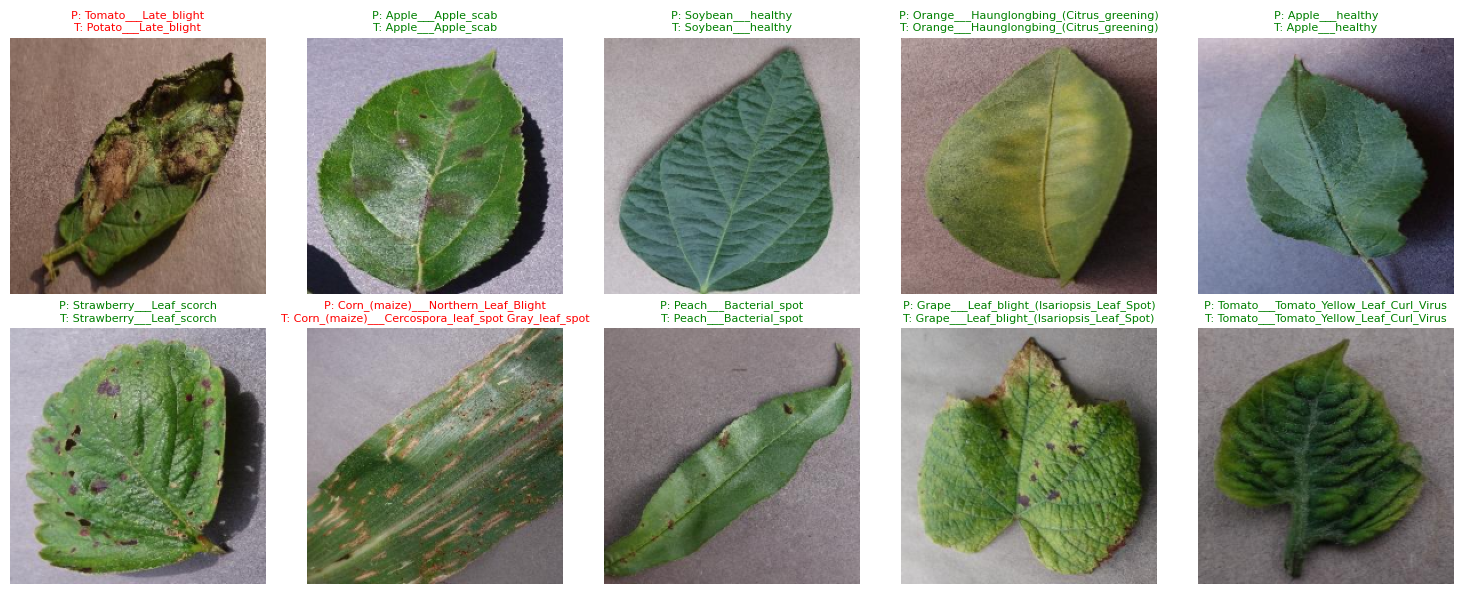

In [32]:
import torch
import matplotlib.pyplot as plt
import numpy as np

cnn_model.eval()

# IMPORTANT FIX HERE
class_names = dataset.classes  

images, labels = next(iter(val_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = cnn_model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(15,6))

for i in range(10):
    plt.subplot(2,5,i+1)

    img = images[i].permute(1,2,0).numpy()
    img = np.clip(img, 0, 1)

    plt.imshow(img)

    true_label = class_names[labels[i]]
    pred_label = class_names[preds[i]]

    color = "green" if preds[i] == labels[i] else "red"

    plt.title(f"P: {pred_label}\nT: {true_label}", 
              color=color, fontsize=8)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
# Create inference.py in project root (outside notebooks)

with open("../inference.py", "w") as f:
    pass

print("✅ inference.py created in project root!")

✅ inference.py created in project root!
